# Lista 3 Problema 3 Individual - De esta nos hacemos ricos - Código para el problema

In [ ]:
!pip install --user --upgrade apafib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for apafib: filename=apafib-0.3.0-py3-none-any.whl size=21323 sha256=73edcbc2378456f834fd72c9b2277179e8da9b2b742fc36a882e48362a75d430
  Stored in directory: /root/.cache/pip/wheels/d4/28/10/7c3ef346cdaffcde387e7e80c2e17d1905a744a00e5d53c9d8
Successfully built apafib
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
!pip install tqdm

In [ ]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm.notebook import tqdm

In [ ]:
class NASDAQ(Dataset):
    def __init__(self, data, pred):
        self.data = torch.Tensor(data).float()
        self.pred = torch.Tensor(pred).float().unsqueeze(1)

    def __getitem__(self, index):
        x = self.data[index]
        y = self.pred[index]

        return x, y

    def __len__(self):
        return len(self.data)

#  BCN_train = torch.utils.data.DataLoader(BCNAir(X_train, y_train), batch_size=32)


In [ ]:
# Funcion para entrenar el modelo
def train_loop(model, train, val, optimizer, patience=5, epochs=100):
    """_Bucle de entrenamiento_

    Args:
        model: red a entrenal
        optimizer: optimizador de pytorch, por ejemplo torch.optim.Adam
        train: datos de entrenamiento
        val: datos de validacion
        epochs: numero de epochs

    Returns:
        _type_: _description_
    """
    def epoch_loss(dataset):
        data_loss = 0.0
        for i, (data, labels) in enumerate(dataset):
            inputs = data.to('cuda')
            y = labels.to('cuda')
            outputs = model(inputs)
            loss = F.mse_loss(outputs, y, reduction="mean")
            data_loss += loss.item()
        return data_loss / i

    def early_stopping(val_loss, patience=5):
        if len(val_loss) > patience:
            if val_loss[-1] > val_loss[-(patience+1)]:
                return True

    hist_loss = {'train': [], 'val': []}
    pbar = tqdm(range(epochs))
    for epoch in pbar:  # bucle para todos los epochs
        for i, (data, labels) in enumerate(train):
            # obtenemos los datos y los subimos a la GPU
            inputs = data.to('cuda')
            y = labels.to('cuda')

            # Reiniciamos los gradientes
            optimizer.zero_grad()

            # Aplicamos los datos al modelo
            outputs = model(inputs)
            # Calculamos la perdida
            loss = F.mse_loss(outputs, y, reduction="mean")

            # Hacemos el paso hacia atras
            loss.backward()
            optimizer.step()

        # Calculamos la perdida en el conjunto de entrenamiento y validacion
        with torch.no_grad():
            hist_loss['train'].append(epoch_loss(train))
            hist_loss['val'].append(epoch_loss(val))

        # Mostramos la perdida en el conjunto de entrenamiento y validacion
        pbar.set_postfix({'train': hist_loss['train'][-1], 'val': hist_loss['val'][-1]})

        # Si la perdida en el conjunto de validacion no disminuye, paramos el entrenamiento
        if early_stopping(hist_loss['val'], patience):
            break

    return hist_loss

# Para el optimizador podemos usar Adam, le pasaremos el siguiente objeto
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# donde model es el modelo que queremos entrenar
# y lr es la tasa de aprendizaje, 1e-4 es un valor comun

In [ ]:
# Clase para definir la arquitectura del MLP
class MLP(nn.Module):
    def __init__(self, input_size,  hidden_layers_sizes, activation=nn.ReLU):
        super(MLP, self).__init__()
        self.layers = []
        self.fc1 = nn.Linear(input_size, hidden_layers_sizes[0])
        self.layers.append(self.fc1)
        self.layers.append(activation())
        for i in range(1, len(hidden_layers_sizes)):
            self.layers.append(nn.Linear(hidden_layers_sizes[i-1], hidden_layers_sizes[i]))
            self.layers.append(activation())
        self.layers = nn.Sequential(*self.layers)
        self.output = nn.Linear(hidden_layers_sizes[-1], 1)

    def forward(self, x):
        return self.output(self.layers(x.view(x.size(0), -1)))

In [ ]:
def test_model(model, test):
    """_Funcion para obtener las predicciones de un modelo en un conjunto de test_

    Poner el modelo en modo evaluacion antes de llamar a esta funcion

    Args:
        model: _modelo entrenado_
        test: _conjunto de test_

    Returns:
        _type_: _valores predichos, valores reales_
    """
    preds = []
    true = []
    for i, (data, val) in enumerate(test):
        inputs = data.to('cuda')
        outputs = model(inputs)
        preds.append(outputs.detach().cpu().numpy())
        true.append(val.detach().cpu().numpy())
    return np.concatenate(preds), np.concatenate(true)

# Apartado A

En este primer apartado se va a hacer un análisis del preprocesado de los datos y se quiere hacer un estudio de las correlaciones para ver si es posible predecir una variable a partir de otras.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from apafib import load_Google

In [ ]:
df = load_Google().copy()

print("Columnas del DataFrame:")
print(df.columns.tolist())

Columnas del DataFrame:
['GOOGLE-P', 'GOOGLE-V', 'GOOGLE-GAP', 'MSFT-P', 'MSFT-V', 'MSFT-GAP', 'AAPL-P', 'AAPL-V', 'AAPL-GAP', 'INTEL-P', 'INTEL-V', 'INTEL-GAP', 'AMD-P', 'AMD-V', 'AMD-GAP']


In [ ]:
target_col = "GOOGLE-P"  # objetivo: precio de cierre de Google
X = df.drop(columns=[target_col])  # todas las variables excepto el target
y = df[target_col]

print(f"Shapes -> df: {df.shape} | X: {X.shape} | y: {y.shape}")
display(df.head())

Shapes -> df: (1259, 15) | X: (1259, 14) | y: (1259,)


,GOOGLE-P,GOOGLE-V,GOOGLE-GAP,MSFT-P,MSFT-V,MSFT-GAP,AAPL-P,AAPL-V,AAPL-GAP,INTEL-P,INTEL-V,INTEL-GAP,AMD-P,AMD-V,AMD-GAP
Date,,,,,,,,,,,,,,,
2017-08-21,45.3330,18846560,0.4800,72.15,17698800,0.78,39.3025,105320280,0.6950,34.92,26479700,0.58,12.05,58786300,0.560
2017-08-22,46.2345,23326400,0.7192,73.16,14333220,0.89,39.9450,86259560,0.4950,34.65,26093400,0.57,12.17,38946780,0.230
2017-08-23,46.3500,21771500,0.5285,72.72,13758650,0.62,39.9950,77507760,0.3975,34.66,19775620,0.43,12.48,44193270,0.585
2017-08-24,46.0640,25323820,0.7670,72.69,17097240,0.79,39.8175,79128680,0.5475,34.71,14283180,0.34,12.50,37161680,0.320
2017-08-25,45.7945,21055280,0.5027,72.82,12790300,0.87,39.9650,100738400,0.3225,34.67,14714810,0.35,12.43,29650370,0.320


In [ ]:
print("NaNs por columna:")
display(df.isna().sum())
print("Total de NaNs en el DataFrame:", int(df.isna().sum().sum()))

NaNs por columna:


,0
GOOGLE-P,0
GOOGLE-V,0
GOOGLE-GAP,0
MSFT-P,0
MSFT-V,0
MSFT-GAP,0
AAPL-P,0
AAPL-V,0
AAPL-GAP,0
INTEL-P,0


Total de NaNs en el DataFrame: 0


Dividimos nuestro conjunto de datos y los estandarizamos. Se nos pide que los datos de entrenamiento sean los 1000 primeros días, los 100 siguientes sean los de validación y el resto vayan a parar a test.

In [ ]:
N_train = 1000
N_val   = 100

df_train = df.iloc[:N_train]
df_val   = df.iloc[N_train:N_train+N_val]
df_test  = df.iloc[N_train+N_val:]

scaler = StandardScaler().fit(df_train.values)
df_train_s = pd.DataFrame(scaler.transform(df_train.values), columns=df_train.columns, index=df_train.index)
df_val_s   = pd.DataFrame(scaler.transform(df_val.values), columns=df_val.columns,   index=df_val.index)
df_test_s  = pd.DataFrame(scaler.transform(df_test.values), columns=df_test.columns,  index=df_test.index)

In [ ]:
print("Estadísticas descriptivas:")
display(df_train.describe().T)

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
GOOGLE-P,1000.0,6.953489e+01,2.172404e+01,4.533300e+01,5.489663e+01,6.045025e+01,7.569475e+01,1.396445e+02
GOOGLE-V,1000.0,3.193524e+07,1.397730e+07,6.935060e+06,2.357304e+07,2.818100e+07,3.645876e+07,1.238938e+08
GOOGLE-GAP,1000.0,1.376538e+00,8.302874e-01,2.380000e-01,7.736250e-01,1.161750e+00,1.735125e+00,5.360000e+00
MSFT-P,1000.0,1.524550e+02,5.854291e+01,7.215000e+01,1.041350e+02,1.371800e+02,2.071175e+02,2.896700e+02
MSFT-V,1000.0,2.949798e+07,1.346547e+07,7.425603e+06,2.095422e+07,2.598310e+07,3.360156e+07,1.109450e+08
MSFT-GAP,1000.0,3.040688e+00,2.271812e+00,3.400000e-01,1.450000e+00,2.400000e+00,3.925750e+00,2.118000e+01
AAPL-P,1000.0,7.295386e+01,3.439012e+01,3.554750e+01,4.480500e+01,5.520125e+01,1.097644e+02,1.491500e+02
AAPL-V,1000.0,1.264305e+08,5.767537e+07,4.544820e+07,8.760557e+07,1.115220e+08,1.494038e+08,4.268848e+08
AAPL-GAP,1000.0,1.626172e+00,1.394003e+00,2.135000e-01,6.693750e-01,1.157500e+00,2.116250e+00,1.281000e+01
INTEL-P,1000.0,5.181178e+01,6.574880e+00,3.465000e+01,4.707000e+01,5.119500e+01,5.683500e+01,6.847000e+01


Vamos a ver como de relacionadas estan todas las variables entre sí y también respecto a nuestra variable objetivo GOOGLE-P.

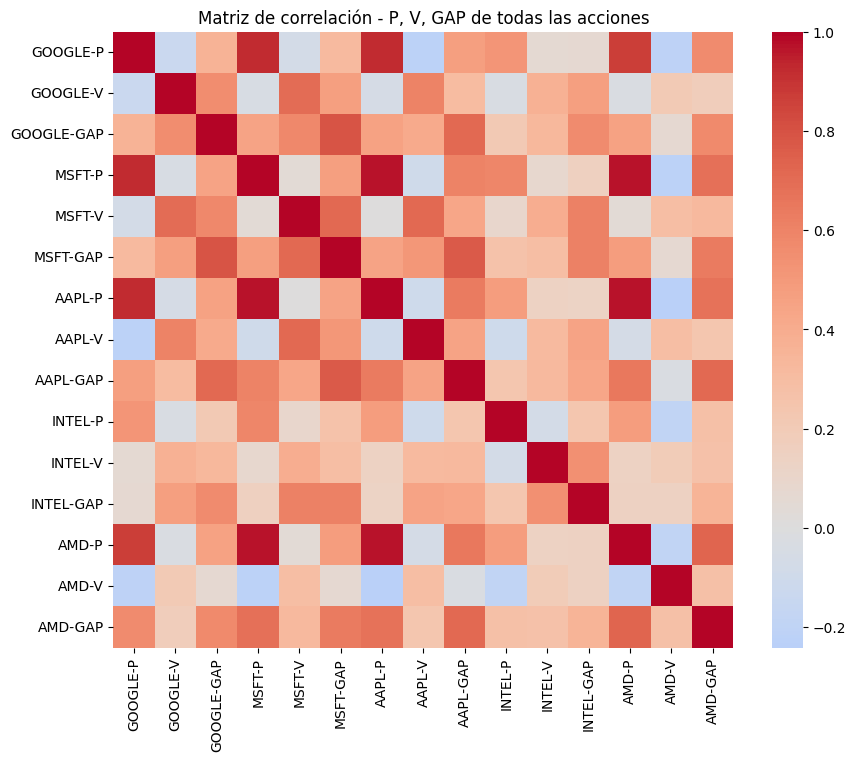

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_train.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación - P, V, GAP de todas las acciones")
plt.show()

In [ ]:
target_col = "GOOGLE-P"
corr_train_target = df_train.corr()[target_col].sort_values(ascending=False)
print("Correlación con GOOGLE-P (TRAIN):")
display(corr_train_target)

Correlación con GOOGLE-P (TRAIN):


,GOOGLE-P
GOOGLE-P,1.000000
MSFT-P,0.925365
AAPL-P,0.920267
AMD-P,0.867624
AMD-GAP,0.567490
INTEL-P,0.522261
AAPL-GAP,0.467489
GOOGLE-GAP,0.361099
MSFT-GAP,0.313720
INTEL-GAP,0.068191


A continuación, se quiere ver como evolucionan el valor de las acciones de cada empresa con el paso del tiempo, para poder ver si siguen o no un mismo patrón.

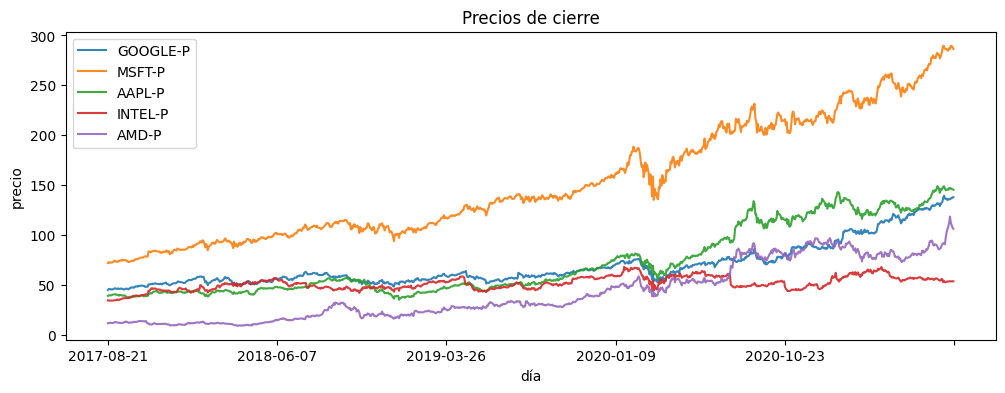

In [ ]:
p_cols = [c for c in df_train.columns if c.endswith("-P")]
v_cols = [c for c in df_train.columns if c.endswith("-V")]
gap_cols = [c for c in df_train.columns if c.endswith("-GAP")]

df_train[p_cols].plot(figsize=(12,4), alpha=0.9)
plt.title("Precios de cierre")
plt.xlabel("día")
plt.ylabel("precio")
plt.show()

**¿Crees que
puede ser posible predecir unas variables a partir de otras?**

Como vemos los resultados muestran que los precios de cierre entre tecnologías se mueven juntos. las correlaciones de MSFT-P, AAPL-P y AMD-P con GOOGLE-P son muy altas, llegando a tomar valores de hasta 0.93. Esto, junto con las curvas de series en el tiempo, indica co-movimiento fuerte y sugiere que el precio de Google se puede predecir razonablemente usando los precios de otras empresas.

En cambio el GAP y el volumen muestran patrones distintos,sus correlaciones con GOOGLE-P son bajas o moderadas (volúmenes incluso correlación negativa). Pueden aportar algo de señal complementaria, pero no son tan predictivos como los precios.

En conlcusión, si es viable predecir unas variables a partir de otras, especialmente el precio de GOOGLE usando precios de MSFT, AAPL, AMD e INTEL.

Ahora se quiere generar los datos con una ventana temporal de 8, de manera que se pueda predecir un día a partir de los siete días anteriores. Por lo que ahora nos quedaremos sin 7 datos de entremamiento, validación y de test. Para calcular los nuevos shape

In [ ]:
H = 7

def data_shifted(df_std: pd.DataFrame, target_col: str, history: int = 7):
    # Lags 1..history para todas las columnas
    lagged_blocks = []
    for k in range(1, history+1):
        lagged_blocks.append(df_std.add_suffix(f"_lag{k}").shift(k))
    X_all = pd.concat(lagged_blocks, axis=1)
    y_all = df_std[target_col]

    # Junta y elimina filas con NaN generados por shift
    data = pd.concat([X_all, y_all], axis=1).dropna()

    # Deja solo GOOGLE-P del último día como y y todos los lags como X
    X = data.drop(columns=[target_col])
    y = data[target_col]
    return X, y

In [ ]:
X_train, y_train = data_shifted(df_train_s, target_col=target_col, history=H)
X_val,   y_val   = data_shifted(df_val_s,   target_col=target_col, history=H)
X_test,  y_test  = data_shifted(df_test_s,  target_col=target_col, history=H)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (993, 105) (993,)
Val:   (93, 105) (93,)
Test:  (152, 105) (152,)


# Apartado B - MLP

Una vez haber hecho la partición de los datos para respetar la ventana de 8 posiciones, se quiere entrenar los datos utilizando modelos MLP. Estos modelos serán de 1 o 2 capas con diferentes tamaños, usando como función de activación ReLU o Sigmoid. Se reutilizarán funciones que se nos han compartido para realizar este método.



In [ ]:
train_loader = torch.utils.data.DataLoader(NASDAQ(X_train.values, y_train.values), batch_size=32, shuffle=True)
val_loader   = torch.utils.data.DataLoader(NASDAQ(X_val.values,   y_val.values),   batch_size=32, shuffle=False)
test_loader  = torch.utils.data.DataLoader(NASDAQ(X_test.values,  y_test.values),  batch_size=32, shuffle=False)

input_size = X_train.shape[1]

print(len(train_loader), len(val_loader), len(test_loader))

32 3 5


Ahora vamos a definir los diferentes tipos de modelos que se van a entrenar, pero antes fijamos la semilla para pytorch, para garantizar los mismos resultados siempre.

In [ ]:
torch.manual_seed(0)

In [ ]:
# 1 capa - activación Relu
Model_ReLu_1_32  = MLP(input_size, hidden_layers_sizes=[32],  activation=nn.ReLU).to('cuda')

Model_ReLu_1_64  = MLP(input_size, hidden_layers_sizes=[64],  activation=nn.ReLU).to('cuda')

Model_ReLu_1_128 = MLP(input_size, hidden_layers_sizes=[128], activation=nn.ReLU).to('cuda')

Model_ReLu_1_256 = MLP(input_size, hidden_layers_sizes=[256], activation=nn.ReLU).to('cuda')

In [ ]:
# 1 capa - activación Sigmoid
Model_Sigmoid_1_32  = MLP(input_size, hidden_layers_sizes=[32],  activation=nn.Sigmoid).to('cuda')

Model_Sigmoid_1_64  = MLP(input_size, hidden_layers_sizes=[64],  activation=nn.Sigmoid).to('cuda')

Model_Sigmoid_1_128 = MLP(input_size, hidden_layers_sizes=[128], activation=nn.Sigmoid).to('cuda')

Model_Sigmoid_1_256 = MLP(input_size, hidden_layers_sizes=[256], activation=nn.Sigmoid).to('cuda')

In [ ]:
# 2 capas (segunda capa = mitad de la primera) - activación ReLU
Model_ReLu_2_32  = MLP(input_size, hidden_layers_sizes=[32, 16],    activation=nn.ReLU).to('cuda')

Model_ReLu_2_64  = MLP(input_size, hidden_layers_sizes=[64, 32],    activation=nn.ReLU).to('cuda')

Model_ReLu_2_128 = MLP(input_size, hidden_layers_sizes=[128, 64],   activation=nn.ReLU).to('cuda')

Model_ReLu_2_256 = MLP(input_size, hidden_layers_sizes=[256, 128],  activation=nn.ReLU).to('cuda')

In [ ]:
# 2 capas (segunda capa = mitad de la primera) - activación Sigmoid
Model_Sigmoid_2_32  = MLP(input_size, hidden_layers_sizes=[32, 16],    activation=nn.Sigmoid).to('cuda')

Model_Sigmoid_2_64  = MLP(input_size, hidden_layers_sizes=[64, 32],    activation=nn.Sigmoid).to('cuda')

Model_Sigmoid_2_128 = MLP(input_size, hidden_layers_sizes=[128, 64],   activation=nn.Sigmoid).to('cuda')

Model_Sigmoid_2_256 = MLP(input_size, hidden_layers_sizes=[256, 128],  activation=nn.Sigmoid).to('cuda')

In [ ]:
# ReLU - 1 capa
optimizer = torch.optim.Adam(Model_ReLu_1_32.parameters(), lr=1e-4)
history_ReLu_1_32  = train_loop(Model_ReLu_1_32,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_1_64.parameters(), lr=1e-4)
history_ReLu_1_64  = train_loop(Model_ReLu_1_64,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_1_128.parameters(), lr=1e-4)
history_ReLu_1_128 = train_loop(Model_ReLu_1_128, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_1_256.parameters(), lr=1e-4)
history_ReLu_1_256 = train_loop(Model_ReLu_1_256, train_loader, val_loader, optimizer, patience=5, epochs=150)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

In [ ]:
# Sigmoid - 1 capa
optimizer = torch.optim.Adam(Model_Sigmoid_1_32.parameters(), lr=1e-4)
history_Sigmoid_1_32  = train_loop(Model_Sigmoid_1_32,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_Sigmoid_1_64.parameters(), lr=1e-4)
history_Sigmoid_1_64  = train_loop(Model_Sigmoid_1_64,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_Sigmoid_1_128.parameters(), lr=1e-4)
history_Sigmoid_1_128 = train_loop(Model_Sigmoid_1_128, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_Sigmoid_1_256.parameters(), lr=1e-4)
history_Sigmoid_1_256 = train_loop(Model_Sigmoid_1_256, train_loader, val_loader, optimizer, patience=5, epochs=150)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

In [ ]:
# ReLU - 2 capas
optimizer = torch.optim.Adam(Model_ReLu_2_32.parameters(), lr=1e-4)
history_ReLu_2_32  = train_loop(Model_ReLu_2_32,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_2_64.parameters(), lr=1e-4)
history_ReLu_2_64  = train_loop(Model_ReLu_2_64,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_2_128.parameters(), lr=1e-4)
history_ReLu_2_128 = train_loop(Model_ReLu_2_128, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_2_256.parameters(), lr=1e-4)
history_ReLu_2_256 = train_loop(Model_ReLu_2_256, train_loader, val_loader, optimizer, patience=5, epochs=150)


  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

In [ ]:
# Sigmoid - 2 capas
optimizer = torch.optim.Adam(Model_Sigmoid_2_32.parameters(), lr=1e-4)
history_Sigmoid_2_32  = train_loop(Model_Sigmoid_2_32,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_Sigmoid_2_64.parameters(), lr=1e-4)
history_Sigmoid_2_64  = train_loop(Model_Sigmoid_2_64,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_Sigmoid_2_128.parameters(), lr=1e-4)
history_Sigmoid_2_128 = train_loop(Model_Sigmoid_2_128, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_Sigmoid_2_256.parameters(), lr=1e-4)
history_Sigmoid_2_256 = train_loop(Model_Sigmoid_2_256, train_loader, val_loader, optimizer, patience=5, epochs=150)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

Como podemos observar en los resultados, la activación de ReLU funciona mucho mejor para el conjunto de datos del problema, ya sea con 1 o con 2 capas. Llegando a solo tener pérdidas de val=0.0502 (1 capa - ReLU) y de val=0.0452 (2 capas - ReLU), siendo este una diferencia muy pequeña respecto a entrenar el modelo con una capa o con dos, con hidden layers de [256] y [128,64] respectivamente.

Respecto a la eficiencia en cuanto al tiempo, ReLU se vuelve a imponer sobre Sigmoid, ya que necesita muchas menos épocas para entrenar los modelos. En concreto Sigmoid puede llegar a tardar 150 épocas, en cambio ReLU tan solo necesita 39 en caso peor. Llegando incluso a tardar tan solo 15 épocas en algún modelo.

Por eso vamos a evaluar los resultados de estos dos mejores modelos (Model_ReLu_1_256 y Model_ReLu_2_128) con MAE y MSE.

In [ ]:
# Evaluación del mejor de 1 capa (ReLU)
preds_test_1, y_test_true = test_model(Model_ReLu_1_256, test_loader)

mae_1 = mean_absolute_error(y_test_true, preds_test_1)
mse_1 = mean_squared_error(y_test_true, preds_test_1)
print("Test (ReLU 1 capa) MAE:", mae_1, " | MSE:", mse_1)

# Evaluación del mejor de 2 capas (ReLU)
preds_test_2, y_test_true = test_model(Model_ReLu_2_128, test_loader)
mae_2 = mean_absolute_error(y_test_true, preds_test_2)
mse_2 = mean_squared_error(y_test_true, preds_test_2)
print("Test (ReLU 2 capas) MAE:", mae_2, " | MSE:", mse_2)

Test (ReLU 1 capa) MAE: 0.24072475731372833  | MSE: 0.08363120257854462
Test (ReLU 2 capas) MAE: 0.22813646495342255  | MSE: 0.07947423309087753


En esta evaluación final, vemos que ambos modelos han obtenido un MAE y MSE similares. Siendo el del modelo de dos capas ligeramente mejor, sobretodo en el MAE. Por todo lo que se ha evaluado y dado que el coste computacional de la segunda capa es asumible, se puede decir que la mejor opción es claramente el modelo de ReLU con 2 capas y hidden layers de [128,64].

# Apartado C
A continuación, se quiere experimentar con unas nuevas funciones de activación: LeakyRELU y SiLU.
Se mantendrá la misma configuración respecto el apartado anterior (mismo optimizador, mismos parámetros, mismos conjuntos de train/validación/test...). Se utilizará el número de capas del modelo que mejores resultados obtuvo (2 capas), explorando diferentes tamaños de las capas.

In [ ]:
# Activación LeakyReLU: 2 hidden layer 128, 64
Model_LeakyReLu_2_128 = MLP(input_size, hidden_layers_sizes=[128, 64], activation=nn.LeakyReLU).to('cuda')
# Activación LeakyReLU: 2 hidden layer 192, 96
Model_LeakyReLu_2_192 = MLP(input_size, hidden_layers_sizes=[192, 96], activation=nn.LeakyReLU).to('cuda')
# Activación LeakyReLU: 2 hidden layer 256, 128
Model_LeakyReLu_2_256 = MLP(input_size, hidden_layers_sizes=[256, 128], activation=nn.LeakyReLU).to('cuda')
# Activación LeakyReLU: 2 hidden layer 320, 160
Model_LeakyReLu_2_320 = MLP(input_size, hidden_layers_sizes=[320, 160], activation=nn.LeakyReLU).to('cuda')

In [ ]:
# Activación SiLU: 2 hidden layer 128, 64
Model_SiLU_2_128 = MLP(input_size, hidden_layers_sizes=[128, 64], activation=nn.SiLU).to('cuda')
# Activación SiLU: 2 hidden layer 192, 96
Model_SiLU_2_192 = MLP(input_size, hidden_layers_sizes=[192, 96], activation=nn.SiLU).to('cuda')
# Activación SiLU: 2 hidden layer 256, 128
Model_SiLU_2_256 = MLP(input_size, hidden_layers_sizes=[256, 128], activation=nn.SiLU).to('cuda')
# Activación SiLU: 2 hidden layer 320, 160
Model_SiLU_2_320 = MLP(input_size, hidden_layers_sizes=[320, 160], activation=nn.SiLU).to('cuda')

In [ ]:
optimizer = torch.optim.Adam(Model_LeakyReLu_2_128.parameters(), lr=1e-4)
history_LeakyReLu_2_128 = train_loop(Model_LeakyReLu_2_128, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_LeakyReLu_2_192.parameters(), lr=1e-4)
history_LeakyReLu_2_192 = train_loop(Model_LeakyReLu_2_192, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_LeakyReLu_2_256.parameters(), lr=1e-4)
history_LeakyReLu_2_256 = train_loop(Model_LeakyReLu_2_256, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_LeakyReLu_2_320.parameters(), lr=1e-4)
history_LeakyReLu_2_320 = train_loop(Model_LeakyReLu_2_320, train_loader, val_loader, optimizer, patience=5, epochs=150)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

In [ ]:
optimizer = torch.optim.Adam(Model_SiLU_2_128.parameters(), lr=1e-4)
history_SiLU_2_128 = train_loop(Model_SiLU_2_128, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_SiLU_2_192.parameters(), lr=1e-4)
history_SiLU_2_192 = train_loop(Model_SiLU_2_192, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_SiLU_2_256.parameters(), lr=1e-4)
history_SiLU_2_256 = train_loop(Model_SiLU_2_256, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_SiLU_2_320.parameters(), lr=1e-4)
history_SiLU_2_320 = train_loop(Model_SiLU_2_320, train_loader, val_loader, optimizer, patience=5, epochs=150)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

En los resultados se ven que los datos reaccionan bien en frente de estas nuevas dos funciones de activación. En general, los modelos de LeakyReLU pierden menos datos de validación, destacando el modelo de LeakyReLU [192,96], siendo este mejor bastante similar al mejor modelo obtenido en el apartado anterior con ReLU, con unas pérdidas de apenas 0.0474.

En cuanto a la velocidad, el mejor modelo de LeakyReLU tardó 13 épocas (prácticamente similar a la mejor del apartado anterior) y SiLU cortó entre las épocas 8 y 11. Seguramente esto pase porque la validación ya no mejoraba.

Por todos estos motivos, LeakyReLU [192,96] se destaca claramente respecto a los demás modelos. Se calculará el MAE y MSE de este y el segundo mejor modelo del apartado (LeakyReLU [256,128]) para acabar de confirmar los resultados anteriores.

In [ ]:
# Evaluación LeakyReLU [192,96]
preds_test_1, y_test_true = test_model(Model_LeakyReLu_2_192, test_loader)

mae_1 = mean_absolute_error(y_test_true, preds_test_1)
mse_1 = mean_squared_error(y_test_true, preds_test_1)
print("Test (LeakyReLU [192,96]) MAE:", mae_1, " | MSE:", mse_1)

# Evaluación LeakyReLU [256,128]
preds_test_2, y_test_true = test_model(Model_LeakyReLu_2_256, test_loader)
mae_2 = mean_absolute_error(y_test_true, preds_test_2)
mse_2 = mean_squared_error(y_test_true, preds_test_2)
print("Test (LeakyReLU [256,128]) MAE:", mae_2, " | MSE:", mse_2)

Test (LeakyReLU [192,96]) MAE: 0.2649155557155609  | MSE: 0.12189096212387085
Test (LeakyReLU [256,128]) MAE: 0.2384362518787384  | MSE: 0.08457039296627045


Aunque en validación LeakyReLU [192,96] llegó a marcar una pérdida baja, vemos que ha obtenido unos resultados mucho peores que LeakyReLU [256,128], por lo que de este apartado se podría decir que el mejor modelo es LeakyReLU [256,128].

Por todo lo que hemos visto y viendo sobretodo que los resultados obtenidos en las pérdidas de los datos de validación son prácticamente iguales pero que en los datos de test si que hay una ligera diferencia, hemos decidido que el mejor modelo hasta ahora ha sido el modelo de dos capas con función de activación ReLU.

# Apartado D

En este apartado vamos a incorporar información sobre como influye la fecha en las cotizaciones, ya sea dependiendo del día de la semana, la semana del año o el mes del año. Partiremos del índice de fechas del DataFrame y extraeremos variables de calendario. Estas nuevas variables se aádirán al DataFrame antes de generar las ventanas temporales y se mantendrán los mismos splits train/validación/test de los anteriores apartados.

Entrenaremos la arquitectura que mejor funcionó hasta ahora (MLP de 2 capas con activación ReLU).

In [ ]:
def add_fecha_datos(df_original: pd.DataFrame) -> pd.DataFrame:
    df = df_original.copy()
    df.index = pd.to_datetime(df.index)

    df['DayOfWeek']  = df.index.dayofweek
    df['WeekOfYear'] = df.index.isocalendar().week.astype(int)
    df['MonthOfYear'] = df.index.month

    return df

df_fecha = add_fecha_datos(df)

Repetimos el proceso de escalar y splitear el nuevo DataFrame con información temporal incorporada.

In [ ]:
N_train = 1000
N_val   = 100

df_train = df_fecha.iloc[:N_train]
df_val   = df_fecha.iloc[N_train:N_train+N_val]
df_test  = df_fecha.iloc[N_train+N_val:]

scaler = StandardScaler().fit(df_train.values)

df_train_s = pd.DataFrame(scaler.transform(df_train.values), columns=df_train.columns, index=df_train.index)
df_val_s   = pd.DataFrame(scaler.transform(df_val.values),   columns=df_val.columns,   index=df_val.index)
df_test_s  = pd.DataFrame(scaler.transform(df_test.values),  columns=df_test.columns,  index=df_test.index)

# Split reutilizando la misma función que el primer apartado
X_train, y_train = data_shifted(df_train_s, target_col=target_col, history=H)
X_val,   y_val   = data_shifted(df_val_s,   target_col=target_col, history=H)
X_test,  y_test  = data_shifted(df_test_s,  target_col=target_col, history=H)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (993, 126) (993,)
Val:   (93, 126) (93,)
Test:  (152, 126) (152,)


Entrenamos el nuevo DataFrame con 2 capas y función activación ReLU.

In [ ]:
input_size = X_train.shape[1]

train_loader = torch.utils.data.DataLoader(NASDAQ(X_train.values, y_train.values), batch_size=32, shuffle=True)
val_loader   = torch.utils.data.DataLoader(NASDAQ(X_val.values,   y_val.values),   batch_size=32, shuffle=False)
test_loader  = torch.utils.data.DataLoader(NASDAQ(X_test.values,  y_test.values),  batch_size=32, shuffle=False)

# 2 capas (segunda capa = mitad de la primera) - activación ReLU
Model_ReLu_2_32  = MLP(input_size, hidden_layers_sizes=[32, 16],    activation=nn.ReLU).to('cuda')
Model_ReLu_2_64  = MLP(input_size, hidden_layers_sizes=[64, 32],    activation=nn.ReLU).to('cuda')
Model_ReLu_2_128 = MLP(input_size, hidden_layers_sizes=[128, 64],   activation=nn.ReLU).to('cuda')
Model_ReLu_2_256 = MLP(input_size, hidden_layers_sizes=[256, 128],  activation=nn.ReLU).to('cuda')

In [ ]:
optimizer = torch.optim.Adam(Model_ReLu_2_32.parameters(), lr=1e-4)
history_ReLu_2_32  = train_loop(Model_ReLu_2_32,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_2_64.parameters(), lr=1e-4)
history_ReLu_2_64  = train_loop(Model_ReLu_2_64,  train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_2_128.parameters(), lr=1e-4)
history_ReLu_2_128 = train_loop(Model_ReLu_2_128, train_loader, val_loader, optimizer, patience=5, epochs=150)

optimizer = torch.optim.Adam(Model_ReLu_2_256.parameters(), lr=1e-4)
history_ReLu_2_256 = train_loop(Model_ReLu_2_256, train_loader, val_loader, optimizer, patience=5, epochs=150)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

Vemos una muy buena respuesta entrenar el nuevo DataFrame con nuestra mejor estructura de los apartados anterior. Sobretodo destacamos el Model_ReLu_2_64 que es el que menos pérdidas por validación tiene (val=0.0381), quedando también muy cerca de este y con muy buen rendimiento el Model_ReLu_2_128. De la misma manera que los apartados anteriores volvemos a ver como se comportan los datos de test de los dos mejores modelos.

In [ ]:
Model_best   = Model_ReLu_2_64
Model_second = Model_ReLu_2_128

preds_best, y_true = test_model(Model_best, test_loader)
mae_best = mean_absolute_error(y_true, preds_best)
mse_best = mean_squared_error(y_true, preds_best)
print("Test (ReLU [64,32]) -> MAE:", mae_best, " | MSE:", mse_best)

preds_second, y_true = test_model(Model_second, test_loader)
mae_second = mean_absolute_error(y_true, preds_second)
mse_second = mean_squared_error(y_true, preds_second)
print("Test (ReLU [128,64]) -> MAE:", mae_second, " | MSE:", mse_second)

Test (ReLU [64,32]) -> MAE: 0.24381963908672333  | MSE: 0.08437035232782364
Test (ReLU [128,64]) -> MAE: 0.2721843719482422  | MSE: 0.11030655354261398


Después de haber añadido al DataFrame las tres variables de fecha (DayOfWeek, WeekOfYear, Month) y de haber entrenado con la arquitectura ganadora (MLP ReLU de 2 capas) explorando tamaños [64,32] y [128,64], vemos que las nuevas variables de calendario han ayudado a bajar la pérdida en validación considerablemente, pero no se han traducido en mejora fuera de muestra de test (obtenemos unos resultados ligeramente peores). Esto nos sugiere que en este dataset concreto, los rasgos de fecha capturan patrones que benefician a la partición de validación. Esto puede ser efecto de estacionalidades específicas en dicho tramo, que a la larga no mejorane l rendimiento final.

# Apartado E

En este último apartado, se quiere ver como reacciona el dataset con un modelo base basado en el modelo de persistencia. Este simplemente tener como método de predicción mirar el valor de las acciones de Google (GOOGLE-P) del día anterior.

In [ ]:
y_true_persist = np.array(y_test)[1:]
y_pred_persist = np.array(y_test)[:-1]

mae_persist = mean_absolute_error(y_true_persist, y_pred_persist)
mse_persist = mean_squared_error(y_true_persist, y_pred_persist)
print(f"Test -> MAE: {mae_persist:.6f} | MSE: {mse_persist:.6f}")

Test -> MAE: 0.108013 | MSE: 0.018650


Podemos observar que los mejores resultados del error medio los hemos obtenido con este modelo. Si lo comparamos con los modelos de MLP, la diferencia es clara a favor de este modelo. Alcanza un MAE de 0.1080 y un MSE de 0.01865 en el conjunto de test. En cambio, MLP en el mejor de los casos obtuvo un MAE de 0.22813646495342255 y un MSE de 0.07947423309087753.

Esto es dado seguramente porque la mayor parte de series financieras como Google presentan cambios pequeños de un día a otro. Si en un día no hay una señal clara hacia donde se va a mover el precio, es decir, no hay una tendencia fuerte ni estacionalidad evidente, cualquier modelo que intente adivinar el cambio puede acabar equivocándose más. Por eso para predicciones de un día vista, la persistencia funciona muy bien y en los resultados lo vemos, ya que el precio del día de antes suele ser prácticamente el mismo que el de el día siguiente.